# Resultados do Modelo e Cenários Geopolíticos

Este notebook funciona como uma camada de **interpretação executiva**. Em vez de reconstruir toda a econometria, ele lê os resultados já produzidos pelo pipeline e organiza a leitura dos principais gráficos.

## Objetivos
- sintetizar a qualidade preditiva do modelo;
- interpretar os coeficientes econômicos mais relevantes;
- comparar retorno real e previsto no período de teste;
- traduzir cenários geopolíticos em impacto esperado sobre o Brent.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

OUTPUT_DIR = Path('../outputs')
metrics = pd.read_csv(OUTPUT_DIR / 'model_metrics.csv')
coeffs = pd.read_csv(OUTPUT_DIR / 'ols_coefficients.csv')
diagnostics = pd.read_csv(OUTPUT_DIR / 'model_diagnostics.csv')
preds = pd.read_csv(OUTPUT_DIR / 'test_predictions.csv', parse_dates=['Date'])
scenarios = pd.read_csv(OUTPUT_DIR / 'scenario_forecasts.csv')


## 1. Tabela de desempenho

A tabela abaixo compara os modelos no treino e no teste. O ponto central aqui não é só escolher o menor erro, mas observar a diferença entre ajuste in-sample e desempenho out-of-sample.

### Como ler
- `R2` maior é melhor, mas em séries financeiras ele costuma ser modesto;
- `RMSE` e `MAE` menores indicam erro médio menor;
- quando o resultado de teste piora muito frente ao treino, isso sugere instabilidade, sobreajuste ou limitação estrutural da base.


In [3]:
metrics


,modelo,amostra,R2,RMSE,MAE
0,OLS contemporâneo,teste,-0.2576,0.0845,0.0653
1,Lasso,teste,-0.8614,0.1029,0.0822
2,Ridge,teste,-1.0064,0.1068,0.0857
3,OLS com lags,teste,-1.2474,0.1130,0.0907
4,OLS com lags,treino,0.3694,0.0782,0.0583
5,OLS contemporâneo,treino,0.0280,0.0969,0.0692


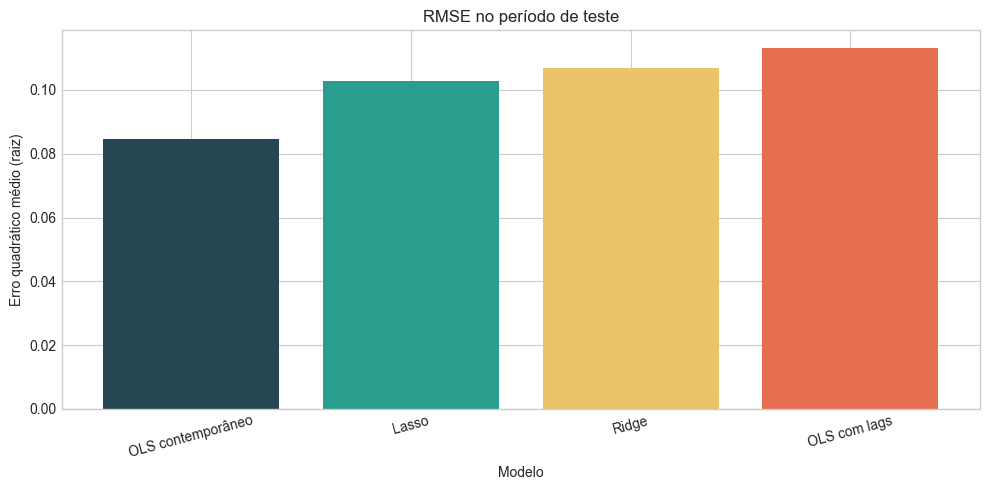

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = metrics[metrics['amostra'] == 'teste'].sort_values('RMSE')
ax.bar(plot_df['modelo'], plot_df['RMSE'], color=['#264653', '#2a9d8f', '#e9c46a', '#e76f51'])
ax.set_title('RMSE no período de teste')
ax.set_ylabel('Erro quadrático médio (raiz)')
ax.set_xlabel('Modelo')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### O que esse gráfico mostra
Esse gráfico resume a **capacidade preditiva fora da amostra**. Se as barras estiverem altas e próximas entre si, o modelo ainda está capturando pouco sinal econômico robusto. Isso é coerente com a atual limitação da base: parte das covariáveis ainda é simulada, o que enfraquece a capacidade de generalização.


## 2. Coeficientes e interpretação econômica

Os coeficientes do OLS contemporâneo medem o sinal e a intensidade das relações condicionais do modelo-base.

### Como ler
- coeficiente positivo: aumento da variável está associado a alta do retorno do Brent;
- coeficiente negativo: aumento da variável está associado a queda do retorno;
- intervalos amplos e `p-values` altos sugerem baixa precisão inferencial.


In [5]:
coeffs.sort_values('p_value')


,variable,coef,std_err,t_stat,p_value,ci_2.5%,ci_97.5%
1,usd_index_std,-0.0131,0.0098,-1.3458,0.1804,-0.0324,0.0062
2,interest_rate_std,0.0118,0.0137,0.8643,0.3888,-0.0152,0.0388
4,oil_stock_std,-0.0066,0.0080,-0.8245,0.4110,-0.0225,0.0092
0,const,-0.0055,0.0101,-0.5486,0.5841,-0.0254,0.0143
3,oil_production_std,0.0044,0.0081,0.5415,0.5890,-0.0116,0.0204
6,geo_risk_ma3_std,-0.0124,0.0337,-0.3692,0.7125,-0.0790,0.0541
5,geopolitical_risk_std,0.0055,0.0319,0.1718,0.8638,-0.0575,0.0685
7,ormuz_dummy,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000


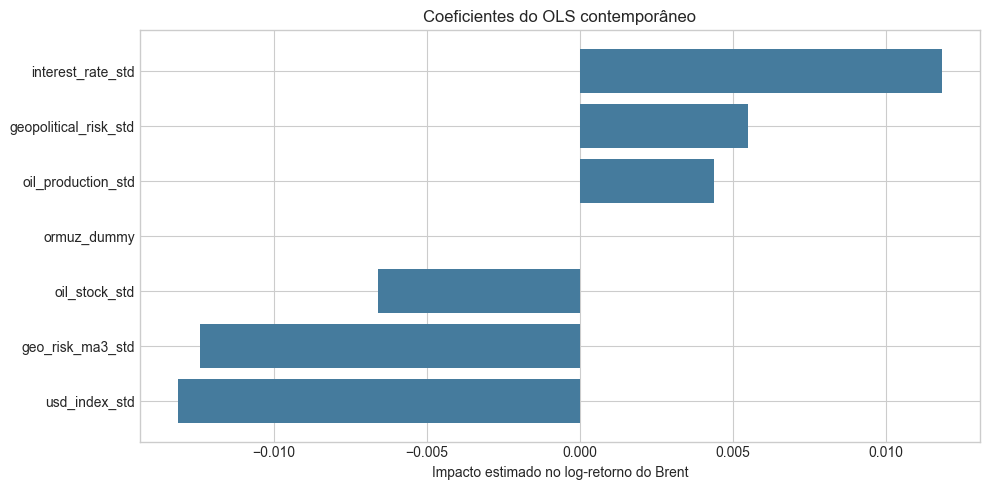

In [6]:
coef_plot = coeffs[coeffs['variable'] != 'const'].copy().sort_values('coef')

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(coef_plot['variable'], coef_plot['coef'], color='#457b9d')
ax.set_title('Coeficientes do OLS contemporâneo')
ax.set_xlabel('Impacto estimado no log-retorno do Brent')
plt.tight_layout()
plt.show()


### O que esse gráfico mostra
Esse gráfico ajuda a identificar quais canais o modelo considera mais relevantes. Em termos geoeconômicos, três leituras são especialmente importantes:
- o bloco de risco geopolítico mede prêmio de risco e medo de restrição de oferta;
- dólar e juros capturam o ambiente financeiro internacional;
- a `dummy` de Ormuz representa um choque estratégico em um chokepoint energético crítico.


## 3. Real versus previsto no teste

Agora observamos se o modelo consegue acompanhar minimamente a direção e a amplitude dos retornos do Brent no período mais recente.


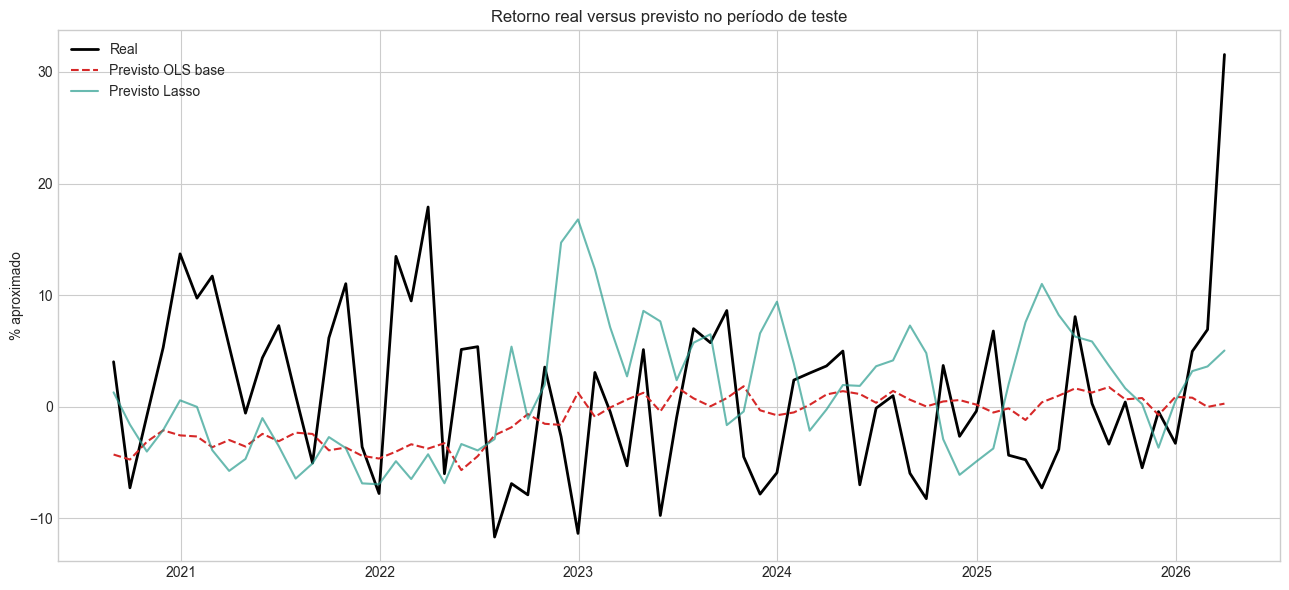

In [7]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(preds['Date'], preds['real_log_return'] * 100, label='Real', color='black', linewidth=2)
ax.plot(preds['Date'], preds['pred_ols_base'] * 100, label='Previsto OLS base', color='#d62828', linestyle='--')
ax.plot(preds['Date'], preds['pred_lasso'] * 100, label='Previsto Lasso', color='#2a9d8f', alpha=0.7)
ax.set_title('Retorno real versus previsto no período de teste')
ax.set_ylabel('% aproximado')
ax.legend()
plt.tight_layout()
plt.show()


### O que esse gráfico mostra
Esse é o gráfico mais importante para honestidade analítica. Quando a curva prevista não acompanha bem a curva real, isso sinaliza que o modelo ainda está melhor como ferramenta de **interpretação estrutural e cenários** do que como previsão operacional precisa.


## 4. Diagnósticos dos resíduos

Diagnósticos não são detalhe técnico; eles dizem se a inferência econométrica merece confiança. O ideal é procurar resíduos menos autocorrelacionados, distribuição não excessivamente distorcida e ausência de padrão forte nos erros.


In [8]:
diagnostics


,metric,value
0,Durbin-Watson,1.1814
1,Jarque-Bera stat,126.5309
2,Jarque-Bera p-value,0.0000
3,"Corr(abs(residual), fitted)",-0.2493


## 5. Cenários geopolíticos

Aqui traduzimos a econometria em linguagem estratégica. O exercício é condicional: mantemos o resto constante e alteramos apenas o bloco geopolítico.


In [9]:
scenarios


,cenario,retorno_previsto_log,retorno_previsto_pct_aprox
0,Bloqueio severo de Ormuz,-0.0174,-1.7422
1,Tensão regional elevada,-0.0009,-0.0884
2,Normalização geopolítica,0.0057,0.5732


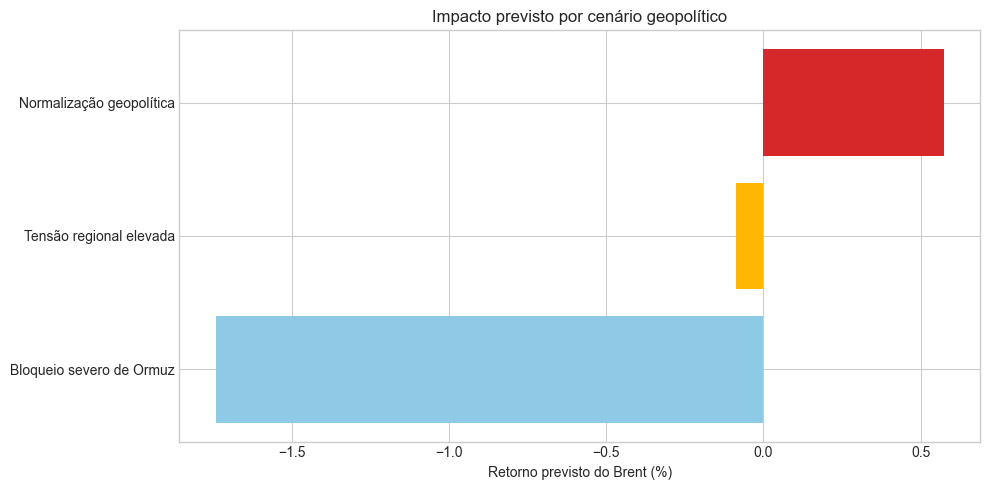

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
scenario_plot = scenarios.sort_values('retorno_previsto_pct_aprox')
ax.barh(scenario_plot['cenario'], scenario_plot['retorno_previsto_pct_aprox'], color=['#8ecae6', '#ffb703', '#d62828'])
ax.set_title('Impacto previsto por cenário geopolítico')
ax.set_xlabel('Retorno previsto do Brent (%)')
plt.tight_layout()
plt.show()


### O que esse gráfico mostra
Esse gráfico sintetiza a mensagem substantiva do projeto: o modelo pode não prever bem cada oscilação mensal, mas ainda assim é útil para comparar **ordens relativas de risco** entre cenários geopolíticos.

## Fechamento
A leitura integrada dos três notebooks fica assim:
- o notebook 01 explica o comportamento estatístico e histórico das séries;
- o notebook 02 formaliza a hipótese em um modelo econométrico;
- o notebook 03 traduz os resultados em narrativa executiva e leitura estratégica.
